# TXED → robust multi-window EQViT magnitude estimation for earthquake early warning

This notebook trains **10 independent EQViT magnitude models** for causal earthquake-early-warning (EEW) magnitude estimation. Every input begins exactly **1.0 s before the P arrival**. The amount of post-P data available to the model is varied systematically:

$
T_{\rm postP}\in\{2,3,4,5,6,7,8,9,10,15\}\ {\rm s}.
$

Thus, for a 2-s model the visible waveform is $[P-1,P+2]$, for a 10-s model it is $[P-1,P+10]$, and for the 15-s model it is $[P-1,P+15]$. These are **post-P EEW update times**, not total input durations. The corresponding visible durations are 3, 4, ..., 11, and 16 s.

## Why train separate models?

An operational EEW system should issue an early estimate and revise it as more waveform arrives. A 2-s model answers *“what magnitude can we estimate only 2 s after P?”*; a 15-s model answers the same question with substantially more source information. Training one model per horizon lets us quantify the latency–accuracy tradeoff directly.

## Causality guarantee

All models receive a common fixed tensor covering $[P-1,P+15]$, but samples later than the selected horizon are **exactly zero-masked before they reach the network**. This has two advantages: (1) it supports EQViT implementations that expect a fixed input length; (2) it guarantees that the 2-s model can never see samples from 2.01 s or later. Each horizon is trained independently and saved as a separate checkpoint.

The notebook also compares accuracy by magnitude, SNR, event, and station, and performs controlled robustness tests for P-pick error, added noise, gain perturbation, missing components, clipping, and short gaps.


In [1]:
from pathlib import Path
import os, random, time, math, json, gc
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from eqvit_torch.models import EQViTMagnitude

SEED = 2026
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else (
    "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else "cpu"
)
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)


PyTorch: 2.10.0+cu128
Device : cuda


## 1. Configuration

Only `TXED_DIR` normally needs editing. `POST_P_WINDOWS_S` defines the ten EEW update times. `PRE_P_S=1.0` is deliberately fixed for every experiment. The current `EQViTMagnitude` architecture expects **exactly 3000 samples** (30 s at 100 Hz), so every experiment uses a `(3000, 3)` tensor spanning **P−1 s to P+29 s**. For a P+T experiment, all samples after P+T are **hard-zero-masked**. Thus the architecture sees its required input shape but cannot access future waveform information. The scientific horizons remain P+2, ..., P+15 s.

For a quick end-to-end software test set `QUICK_RUN=True`. Use `False` for the scientific experiment.


In [2]:
# EDIT THIS PATH ONLY
TXED_DIR = Path("/data/DATALIB/TXED")
H5_PATH = TXED_DIR / "TXED_20231111.h5"
ID_PATH = TXED_DIR / "ID_20231111.npy"

OUTPUT_DIR = Path("./outputs/txed_eqvit_magnitude_multiwindow_eew")
MODEL_DIR = OUTPUT_DIR / "models"
FIG_DIR = OUTPUT_DIR / "figures"
for d in [OUTPUT_DIR, MODEL_DIR, FIG_DIR]: d.mkdir(parents=True, exist_ok=True)

FS = 100
PRE_P_S = 1.0
POST_P_WINDOWS_S = [2,3,4,5,6,7,8,9,10,15]  # exactly 10 models
MAX_POST_P_S = max(POST_P_WINDOWS_S)

# IMPORTANT: the current EQViTMagnitude implementation is architecturally fixed
# to 3000 input samples (30 s at 100 Hz). Its regression head expects the
# corresponding token dimension. Therefore ALL ten EEW models receive a
# (3000, 3) tensor. Causality is enforced by zero-masking every sample after
# the requested P+T horizon. The network never sees future waveform values.
MODEL_N = 3000
FULL_N = MODEL_N
MODEL_TOTAL_S = MODEL_N / FS          # 30 s tensor
MODEL_POST_P_S = MODEL_TOTAL_S - PRE_P_S  # P-1 s through P+29 s
PRE_N = int(round(PRE_P_S * FS))      # 100 samples

QUICK_RUN = False
MAX_EPOCHS = 5 if QUICK_RUN else 1000
PATIENCE = 3 if QUICK_RUN else 25
BATCH_SIZE = 32 if QUICK_RUN else 128
NUM_WORKERS = 0
LR = 1e-3
WEIGHT_DECAY = 1e-5
BALANCED_SAMPLING = True

# Robust-training augmentation. All perturbations are applied only to samples
# already visible at the selected EEW horizon; no future data can leak in.
ROBUST_AUGMENT = True
TRAIN_PICK_JITTER_S = 0.20
AUG_NOISE_PROB = 0.35
AUG_GAIN_PROB = 0.25
AUG_CHANNEL_DROPOUT_PROB = 0.05
AUG_CLIP_PROB = 0.05
AUG_GAP_PROB = 0.05

assert len(POST_P_WINDOWS_S) == 10
assert PRE_P_S == 1.0
assert H5_PATH.exists(), f"Missing {H5_PATH}"
assert ID_PATH.exists(), f"Missing {ID_PATH}"
print("Models:", POST_P_WINDOWS_S)
print(f"Model input: {FULL_N} samples = P-{PRE_P_S:.1f}s to P+{MODEL_POST_P_S:.0f}s")
print(f"Scientific EEW horizons: P+{min(POST_P_WINDOWS_S)} to P+{MAX_POST_P_S} s")
print("Samples after each horizon are hard-zero-masked (no future-data leakage).")
assert FULL_N == 3000, "EQViTMagnitude currently requires 3000 samples"


Models: [2, 3, 4, 5, 6, 7, 8, 9, 10, 15]
Model input: 3000 samples = P-1.0s to P+29s
Scientific EEW horizons: P+2 to P+15 s
Samples after each horizon are hard-zero-masked (no future-data leakage).


## 2. EEW window geometry and causal masking

For horizon $T$, the visible interval is

$
[P-1\ {\rm s},\;P+T].
$

The common tensor contains $[P-1,P+15]$. Define the causal mask

$
m_T(t)=\begin{cases}1,&t\le T\\0,&t>T.\end{cases}
$

The network input is $x_T(t)=m_T(t)x(t)$. Consequently, the early model cannot exploit later S waves, coda, or any other future information. The plot below makes the exact visible/hidden regions explicit.


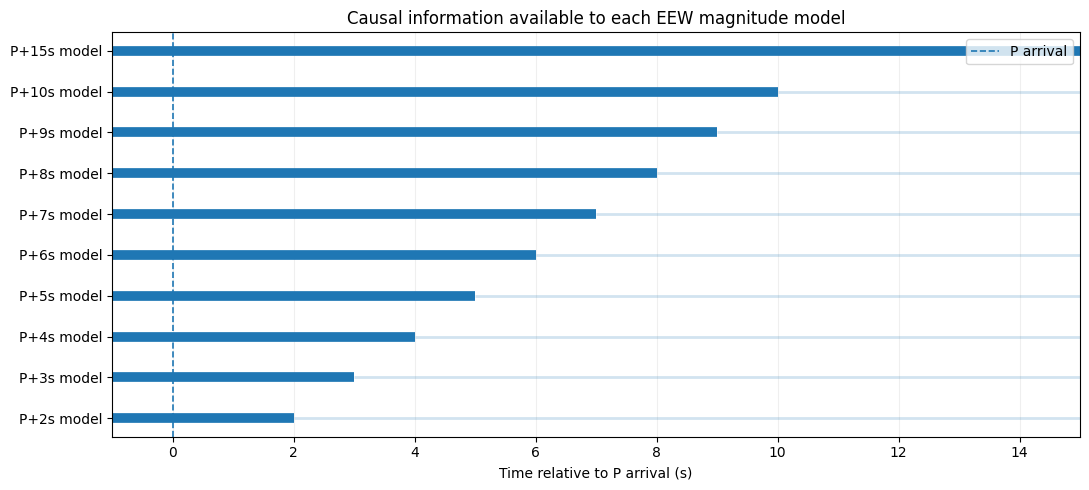

In [3]:
fig, ax = plt.subplots(figsize=(11,5))
y = np.arange(len(POST_P_WINDOWS_S))
for j, T in enumerate(POST_P_WINDOWS_S):
    ax.hlines(j, -PRE_P_S, T, lw=7)
    ax.hlines(j, T, MAX_POST_P_S, lw=2, alpha=.20)
ax.axvline(0, ls="--", lw=1.2, label="P arrival")
ax.set_yticks(y, [f"P+{T}s model" for T in POST_P_WINDOWS_S])
ax.set_xlim(-PRE_P_S, MAX_POST_P_S)
ax.set_xlabel("Time relative to P arrival (s)")
ax.set_title("Causal information available to each EEW magnitude model")
ax.grid(axis="x", alpha=.2)
ax.legend()
plt.tight_layout(); plt.show()


## 3. Audit TXED and build a compact metadata table

We scan metadata first and do not load all waveform arrays into memory. The split is performed by **event**, not by waveform, to prevent the same earthquake appearing in both training and test sets.


(312231, 6) waveforms | 21751 events


,id,event_id,station,magnitude,p_sample,snr_mean
0,texnet2023qnms_CV01_EV,texnet2023qnms,CV01,2.856377,535.0,NaN
1,texnet2023qnms_SA04_EV,texnet2023qnms,SA04,2.856377,650.0,NaN
2,texnet2023qnms_SA06_EV,texnet2023qnms,SA06,2.856377,1065.0,NaN
3,texnet2023qnms_SA07_EV,texnet2023qnms,SA07,2.856377,321.0,NaN
4,texnet2023qnms_SA09_EV,texnet2023qnms,SA09,2.856377,991.0,NaN


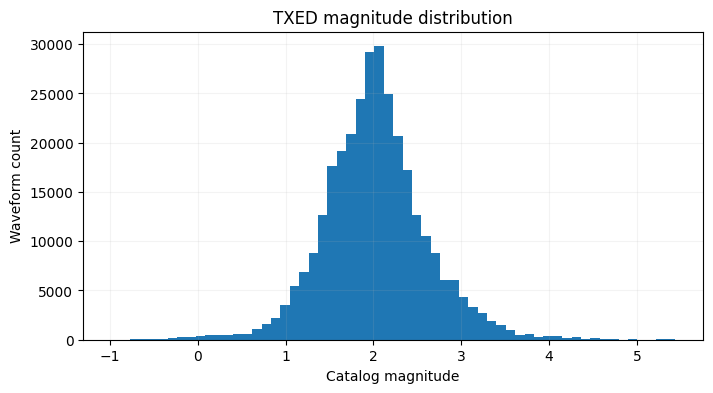

In [4]:
all_ids = np.load(ID_PATH, allow_pickle=True).astype(str)
signal_ids = np.array([x for x in all_ids if x.split("_")[-1] == "EV"])
if QUICK_RUN: signal_ids = signal_ids[:min(12000, len(signal_ids))]

def sf(x, default=np.nan):
    try: return float(x)
    except Exception: return default

rows=[]
with h5py.File(H5_PATH,"r") as f:
    for wid in signal_ids:
        if wid not in f: continue
        g=f[wid]; a=g.attrs
        if "data" not in g or "p_arrival_sample" not in a or "magnitude" not in a: continue
        mag=sf(a.get("magnitude")); p=sf(a.get("p_arrival_sample"))
        if not np.isfinite(mag) or not np.isfinite(p): continue
        event_id=str(a.get("event_id", "_".join(wid.split("_")[:-2])))
        station=str(a.get("station", wid.split("_")[0] if "_" in wid else "UNK"))
        snrs=[]
        for k in ["snr_db","snr","snr_z","snr_n","snr_e"]:
            v=sf(a.get(k));
            if np.isfinite(v): snrs.append(v)
        rows.append(dict(id=wid,event_id=event_id,station=station,magnitude=mag,
                         p_sample=p,snr_mean=np.mean(snrs) if snrs else np.nan))
meta=pd.DataFrame(rows).drop_duplicates("id").reset_index(drop=True)
print(meta.shape, "waveforms |", meta.event_id.nunique(), "events")
display(meta.head())

fig, ax=plt.subplots(figsize=(8,4)); ax.hist(meta.magnitude,bins=60)
ax.set(xlabel="Catalog magnitude",ylabel="Waveform count",title="TXED magnitude distribution")
ax.grid(alpha=.15); plt.show()


## 4. Event-disjoint train/validation/test split

The exact same event split is reused for **all ten horizons**, which is essential for a fair latency–accuracy comparison.


In [5]:
events=np.array(sorted(meta.event_id.unique()))
rng=np.random.default_rng(SEED); rng.shuffle(events)
n=len(events); ntr=int(.80*n); nv=int(.10*n)
train_events=set(events[:ntr]); val_events=set(events[ntr:ntr+nv]); test_events=set(events[ntr+nv:])
train_df=meta[meta.event_id.isin(train_events)].reset_index(drop=True)
val_df=meta[meta.event_id.isin(val_events)].reset_index(drop=True)
test_df=meta[meta.event_id.isin(test_events)].reset_index(drop=True)
print("waveforms:",len(train_df),len(val_df),len(test_df))
print("events   :",train_df.event_id.nunique(),val_df.event_id.nunique(),test_df.event_id.nunique())
assert set(train_df.event_id).isdisjoint(val_df.event_id)
assert set(train_df.event_id).isdisjoint(test_df.event_id)
assert set(val_df.event_id).isdisjoint(test_df.event_id)

split_table=pd.DataFrame({
    "split":["train","validation","test"],
    "waveforms":[len(train_df),len(val_df),len(test_df)],
    "events":[train_df.event_id.nunique(),val_df.event_id.nunique(),test_df.event_id.nunique()]})
display(split_table)


waveforms: 249713 31062 31456
events   : 17400 2175 2176


,split,waveforms,events
0,train,249713,17400
1,validation,31062,2175
2,test,31456,2176


## 5. Window extraction and robust causal augmentation

`extract_causal_window` always starts at **P−1 s** and returns the same 16-s tensor shape. It zeroes everything after the selected post-P horizon.

Training augmentation is intentionally moderate. It simulates automatic-pick timing error, noise, amplitude calibration variation, occasional missing components, clipping, and short telemetry gaps. Validation/test data remain clean unless a stress test explicitly requests a perturbation.


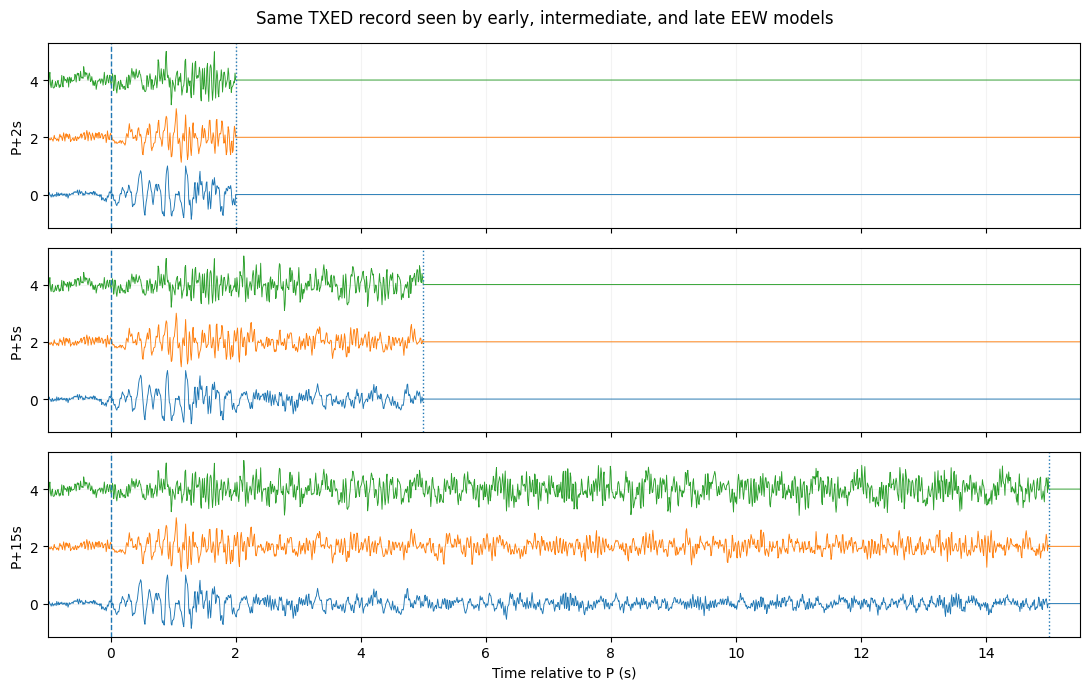

In [6]:
def extract_causal_window(x, p_sample, post_p_s, fs=FS, pre_p_s=PRE_P_S, n_samples=FULL_N):
    """Return the fixed 3000-sample EQViT tensor with a strict causal mask.

    Tensor coordinates are P-1 s ... P+29 s. Only P-1 s ... P+post_p_s
    contains waveform data; every later sample is exactly zero.
    """
    p=int(round(p_sample)); pre=int(round(pre_p_s*fs)); n=int(n_samples)
    start=p-pre
    out=np.zeros((n,3),np.float32)
    a,b=max(0,start),min(len(x),start+n)
    if b>a: out[a-start:b-start]=x[a:b]
    visible_n=int(round((pre_p_s+post_p_s)*fs))
    if visible_n > n:
        raise ValueError(f"Requested visible window ({visible_n} samples) exceeds model input ({n})")
    out[visible_n:]=0.0  # HARD CAUSAL MASK: no samples after P+post_p_s
    assert out.shape == (FULL_N, 3)
    return out

def robust_augment(w, visible_n, rng):
    z=w.copy(); v=z[:visible_n]
    if rng.random()<AUG_NOISE_PROB:
        rms=np.sqrt(np.mean(v*v,axis=0,keepdims=True)+1e-12)
        frac=rng.uniform(.02,.20)
        v += rng.normal(0,1,v.shape).astype(np.float32)*rms*frac
    if rng.random()<AUG_GAIN_PROB:
        common=rng.uniform(.80,1.25); component=rng.uniform(.90,1.10,size=(1,3))
        v *= (common*component).astype(np.float32)
    if rng.random()<AUG_CHANNEL_DROPOUT_PROB:
        v[:,int(rng.integers(0,3))]=0
    if rng.random()<AUG_CLIP_PROB:
        q=np.quantile(np.abs(v),rng.uniform(.94,.995));
        if q>0: np.clip(v,-q,q,out=v)
    if rng.random()<AUG_GAP_PROB and visible_n>50:
        L=int(rng.integers(10,min(80,visible_n)))
        a=int(rng.integers(0,max(1,visible_n-L))); v[a:a+L]=0
    z[:visible_n]=v; z[visible_n:]=0
    return z

class TXEDMagnitudeDataset(Dataset):
    def __init__(self,h5_path,frame,post_p_s,training=False,seed=SEED):
        self.h5_path=str(h5_path); self.frame=frame.reset_index(drop=True)
        self.post_p_s=float(post_p_s); self.training=training; self.seed=seed; self._h5=None
    def __len__(self): return len(self.frame)
    def _file(self):
        if self._h5 is None: self._h5=h5py.File(self.h5_path,"r")
        return self._h5
    def __getitem__(self,i):
        r=self.frame.iloc[i]; g=self._file()[r.id]; x=np.asarray(g["data"],np.float32)
        p0=int(round(float(g.attrs["p_arrival_sample"])))
        rng=np.random.default_rng(self.seed+i+int(self.post_p_s*10000))
        dp=0
        if self.training and ROBUST_AUGMENT:
            dp=int(round(rng.uniform(-TRAIN_PICK_JITTER_S,TRAIN_PICK_JITTER_S)*FS))
        w=extract_causal_window(x,p0+dp,self.post_p_s)
        visible_n=int(round((PRE_P_S+self.post_p_s)*FS))
        # Remove pre-event/component DC using only the first PRE_P_S of the available tensor.
        baseline=w[:PRE_N].mean(axis=0,keepdims=True)
        w[:visible_n]-=baseline; w[visible_n:]=0
        if self.training and ROBUST_AUGMENT: w=robust_augment(w,visible_n,rng)
        y=np.float32(g.attrs["magnitude"])
        return torch.from_numpy(np.ascontiguousarray(w)),torch.tensor(y),{
            "id":r.id,"event_id":r.event_id,"station":r.station,
            "snr_mean":np.float32(r.snr_mean),"p_jitter":dp}

# Visual proof that the mask is causal.
wid=test_df.iloc[0].id
with h5py.File(H5_PATH,"r") as f:
    g=f[wid]; x=np.asarray(g["data"],np.float32); p=float(g.attrs["p_arrival_sample"])
    fig,axs=plt.subplots(3,1,figsize=(11,7),sharex=True)
    for ax,T in zip(axs,[2,5,15]):
        w=extract_causal_window(x,p,T); t=np.arange(FULL_N)/FS-PRE_P_S
        s=np.max(np.abs(w),axis=0); s[s==0]=1
        for c in range(3): ax.plot(t,w[:,c]/s[c]+2*c,lw=.65)
        ax.axvline(0,ls="--",lw=1); ax.axvline(T,ls=":",lw=1)
        ax.set_ylabel(f"P+{T}s")
        ax.set_xlim(-PRE_P_S, MAX_POST_P_S + 0.5)
        ax.grid(alpha=.15)
    axs[-1].set_xlabel("Time relative to P (s)")
    fig.suptitle("Same TXED record seen by early, intermediate, and late EEW models")
    plt.tight_layout(); plt.show()


## 6. Fair loaders and magnitude-balanced sampling

Every horizon uses the same split, sampling strategy, optimizer family, loss, early-stopping rule, and architecture. The **only intended scientific difference is how much post-P waveform is visible**.


In [7]:
def magnitude_weights(mags,width=.5):
    mags=np.asarray(mags,float); lo=math.floor(np.nanmin(mags)/width)*width
    hi=math.ceil(np.nanmax(mags)/width)*width+width; edges=np.arange(lo,hi+1e-9,width)
    idx=np.clip(np.digitize(mags,edges)-1,0,len(edges)-2); counts=np.bincount(idx,minlength=len(edges)-1)
    w=1/np.maximum(counts[idx],1); return w/w.mean()

def make_loaders(T):
    tr=TXEDMagnitudeDataset(H5_PATH,train_df,T,training=True)
    va=TXEDMagnitudeDataset(H5_PATH,val_df,T,training=False)
    te=TXEDMagnitudeDataset(H5_PATH,test_df,T,training=False)
    if BALANCED_SAMPLING:
        ww=magnitude_weights(train_df.magnitude.values)
        gen=torch.Generator(); gen.manual_seed(SEED+int(T*100))
        sampler=WeightedRandomSampler(torch.as_tensor(ww,dtype=torch.double),len(ww),replacement=True,generator=gen)
        trl=DataLoader(tr,batch_size=BATCH_SIZE,sampler=sampler,num_workers=NUM_WORKERS,pin_memory=DEVICE=="cuda")
    else:
        trl=DataLoader(tr,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,pin_memory=DEVICE=="cuda")
    val=DataLoader(va,batch_size=BATCH_SIZE*2,shuffle=False,num_workers=NUM_WORKERS,pin_memory=DEVICE=="cuda")
    tes=DataLoader(te,batch_size=BATCH_SIZE*2,shuffle=False,num_workers=NUM_WORKERS,pin_memory=DEVICE=="cuda")
    return trl,val,tes


## 7. Training/evaluation functions

Model selection uses **validation MAE only**. The locked test set is evaluated once after the best checkpoint for each horizon is restored. Smooth-L1 loss and gradient clipping reduce sensitivity to outliers.


In [8]:
criterion=nn.SmoothL1Loss(beta=.25)

def run_epoch(model,loader,optimizer=None):
    training=optimizer is not None; model.train(training); ys=[]; ps=[]; loss_sum=0.; n=0
    for x,y,_ in loader:
        x=x.to(DEVICE,non_blocking=True); y=y.to(DEVICE,non_blocking=True)
        if training: optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            pred=model(x).reshape(-1); loss=criterion(pred,y.reshape(-1))
            if training:
                loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),5.0); optimizer.step()
        loss_sum+=float(loss.detach())*len(x); n+=len(x)
        ys.append(y.detach().cpu().numpy()); ps.append(pred.detach().cpu().numpy())
    y=np.concatenate(ys); p=np.concatenate(ps); e=p-y
    return dict(loss=loss_sum/max(n,1),mae=float(np.mean(np.abs(e))),rmse=float(np.sqrt(np.mean(e*e))),
                bias=float(np.mean(e)),std=float(np.std(e)),y=y,pred=p)

def train_one_horizon(T):
    print("\n"+"="*78+f"\nTRAINING EEW MODEL: P-1 s → P+{T} s\n"+"="*78)
    # Re-seed so initialization protocol is reproducible for every horizon.
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model=EQViTMagnitude().to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
    sch=torch.optim.lr_scheduler.ReduceLROnPlateau(opt,mode="min",factor=np.sqrt(.1),patience=10)
    trl,val,tes=make_loaders(T)
    best=MODEL_DIR/f"eqvit_magnitude_Pm1_Pp{T:02d}s_best.pt"
    history=[]; best_mae=np.inf; bad=0
    for epoch in range(1,MAX_EPOCHS+1):
        t0=time.time(); tr=run_epoch(model,trl,opt); va=run_epoch(model,val); sch.step(va["mae"])
        row=dict(post_p_s=T,epoch=epoch,train_mae=tr["mae"],val_mae=va["mae"],val_rmse=va["rmse"],
                 lr=opt.param_groups[0]["lr"],seconds=time.time()-t0); history.append(row)
        print(f"T={T:>2}s E{epoch:03d} train={tr['mae']:.3f} val={va['mae']:.3f} "
              f"RMSE={va['rmse']:.3f} lr={row['lr']:.2e} {row['seconds']:.1f}s")
        if va["mae"]<best_mae-1e-4:
            best_mae=va["mae"]; bad=0
            torch.save({"state_dict":model.state_dict(),"epoch":epoch,"val_mae":best_mae,
                        "config":{"pre_p_s":PRE_P_S,"post_p_s":T,"fs":FS,"tensor_samples":FULL_N,
                                  "tensor_end_relative_to_p_s":MODEL_POST_P_S,
                                  "visible_samples":int((PRE_P_S+T)*FS),"causal_mask":True,
                                  "robust_augment":ROBUST_AUGMENT,"event_disjoint":True,
                                  "balanced_sampling":BALANCED_SAMPLING}},best)
        else: bad+=1
        if bad>=PATIENCE: print("Early stopping."); break
    pd.DataFrame(history).to_csv(OUTPUT_DIR/f"history_Pp{T:02d}s.csv",index=False)
    ck=torch.load(best,map_location=DEVICE); model.load_state_dict(ck["state_dict"])
    te=run_epoch(model,tes)
    pred=test_df.copy().reset_index(drop=True); pred["post_p_s"]=T
    pred["predicted_magnitude"]=te["pred"]; pred["residual"]=pred.predicted_magnitude-pred.magnitude
    pred["abs_error"]=pred.residual.abs(); pred.to_csv(OUTPUT_DIR/f"test_predictions_Pp{T:02d}s.csv",index=False)
    summary=dict(post_p_s=T,visible_duration_s=PRE_P_S+T,best_epoch=ck["epoch"],val_mae=ck["val_mae"],
                 test_mae=te["mae"],test_rmse=te["rmse"],test_bias=te["bias"],test_std=te["std"],checkpoint=str(best))
    del trl,val,tes; gc.collect()
    if DEVICE=="cuda": torch.cuda.empty_cache()
    return model,pred,summary


## 8. Train and save all 10 EEW models

This is the computationally expensive cell. It writes one best checkpoint per horizon immediately, so a completed horizon is not lost if a later run is interrupted.


In [9]:
# Architecture/causality sanity check -- run this before training all ten models.
# It catches the exact 1600-vs-3000 shape problem that would otherwise fail in the head.
_sanity_ds = TXEDMagnitudeDataset(H5_PATH, train_df.iloc[:min(2, len(train_df))], 2, training=False)
_sanity_x, _sanity_y, _ = _sanity_ds[0]
print("Dataset tensor shape:", tuple(_sanity_x.shape))
assert tuple(_sanity_x.shape) == (3000, 3)
assert torch.count_nonzero(_sanity_x[int((PRE_P_S+2)*FS):]) == 0, "Future samples are not fully masked"

_sanity_model = EQViTMagnitude().to(DEVICE)
with torch.no_grad():
    _sanity_pred = _sanity_model(_sanity_x.unsqueeze(0).to(DEVICE))
print("Model forward pass OK; output shape:", tuple(_sanity_pred.shape))
del _sanity_model, _sanity_ds
if DEVICE == "cuda": torch.cuda.empty_cache()


Dataset tensor shape: (3000, 3)
Model forward pass OK; output shape: (1,)


### Why the tensor is 3000 samples even for a P+2 s model

`EQViTMagnitude` currently has a fixed-size regression head. At 100 Hz it expects 3000 samples, corresponding to P−1 to P+29 s for this notebook. **This does not mean the early EEW models use 29 s of future data.** For the P+2 s model, only the first 300 samples (1 s pre-P + 2 s post-P) can contain waveform values; samples 300:3000 are exactly zero. The same rule is applied independently for every horizon.


In [10]:
summaries=[]; all_predictions=[]
for T in POST_P_WINDOWS_S:
    model_T,pred_T,summary_T=train_one_horizon(T)
    summaries.append(summary_T); all_predictions.append(pred_T)
    del model_T; gc.collect()
    if DEVICE=="cuda": torch.cuda.empty_cache()

summary_df=pd.DataFrame(summaries).sort_values("post_p_s")
pred_all=pd.concat(all_predictions,ignore_index=True)
summary_df.to_csv(OUTPUT_DIR/"multiwindow_summary.csv",index=False)
pred_all.to_csv(OUTPUT_DIR/"multiwindow_test_predictions.csv",index=False)
display(summary_df)



TRAINING EEW MODEL: P-1 s → P+2 s
T= 2s E001 train=0.531 val=0.432 RMSE=0.580 lr=1.00e-03 147.6s
T= 2s E002 train=0.425 val=0.450 RMSE=0.601 lr=1.00e-03 129.3s
T= 2s E003 train=0.397 val=0.436 RMSE=0.604 lr=1.00e-03 125.1s
T= 2s E004 train=0.380 val=0.394 RMSE=0.530 lr=1.00e-03 123.2s
T= 2s E005 train=0.366 val=0.408 RMSE=0.540 lr=1.00e-03 120.2s
T= 2s E006 train=0.358 val=0.398 RMSE=0.527 lr=1.00e-03 119.9s
T= 2s E007 train=0.349 val=0.421 RMSE=0.565 lr=1.00e-03 120.3s
T= 2s E008 train=0.339 val=0.388 RMSE=0.525 lr=1.00e-03 120.1s
T= 2s E009 train=0.335 val=0.387 RMSE=0.518 lr=1.00e-03 126.4s
T= 2s E010 train=0.329 val=0.404 RMSE=0.534 lr=1.00e-03 125.4s
T= 2s E011 train=0.326 val=0.387 RMSE=0.510 lr=1.00e-03 121.0s
T= 2s E012 train=0.320 val=0.376 RMSE=0.507 lr=1.00e-03 120.0s
T= 2s E013 train=0.317 val=0.370 RMSE=0.499 lr=1.00e-03 121.2s
T= 2s E014 train=0.313 val=0.376 RMSE=0.506 lr=1.00e-03 121.1s
T= 2s E015 train=0.309 val=0.370 RMSE=0.499 lr=1.00e-03 120.7s
T= 2s E016 train=0.3

,post_p_s,visible_duration_s,best_epoch,val_mae,test_mae,test_rmse,test_bias,test_std,checkpoint
0,2,3.0,88,0.295232,0.294306,0.407914,-0.026539,0.407050,outputs/txed_eqvit_magnitude_multiwindow_eew/m...
1,3,4.0,60,0.256254,0.255118,0.349620,-0.067099,0.343121,outputs/txed_eqvit_magnitude_multiwindow_eew/m...
2,4,5.0,48,0.258802,0.261350,0.359267,-0.052085,0.355472,outputs/txed_eqvit_magnitude_multiwindow_eew/m...
3,5,6.0,18,0.245535,0.248894,0.346689,-0.004225,0.346664,outputs/txed_eqvit_magnitude_multiwindow_eew/m...
4,6,7.0,32,0.221005,0.225306,0.322318,-0.026440,0.321232,outputs/txed_eqvit_magnitude_multiwindow_eew/m...
5,7,8.0,32,0.233331,0.235742,0.336610,0.005901,0.336558,outputs/txed_eqvit_magnitude_multiwindow_eew/m...
6,8,9.0,46,0.202807,0.203934,0.293013,-0.035489,0.290856,outputs/txed_eqvit_magnitude_multiwindow_eew/m...
7,9,10.0,46,0.194475,0.196248,0.279198,-0.064603,0.271622,outputs/txed_eqvit_magnitude_multiwindow_eew/m...
8,10,11.0,37,0.212130,0.212766,0.294065,-0.085426,0.281383,outputs/txed_eqvit_magnitude_multiwindow_eew/m...
9,15,16.0,62,0.168976,0.170324,0.240426,-0.070426,0.229880,outputs/txed_eqvit_magnitude_multiwindow_eew/m...


## 9. Main EEW result: latency versus accuracy

For EEW, the key curve is error versus seconds after P. Earlier estimates are more valuable operationally, while later estimates usually contain more source information. We therefore plot MAE, RMSE, bias, and residual scatter as functions of update time.


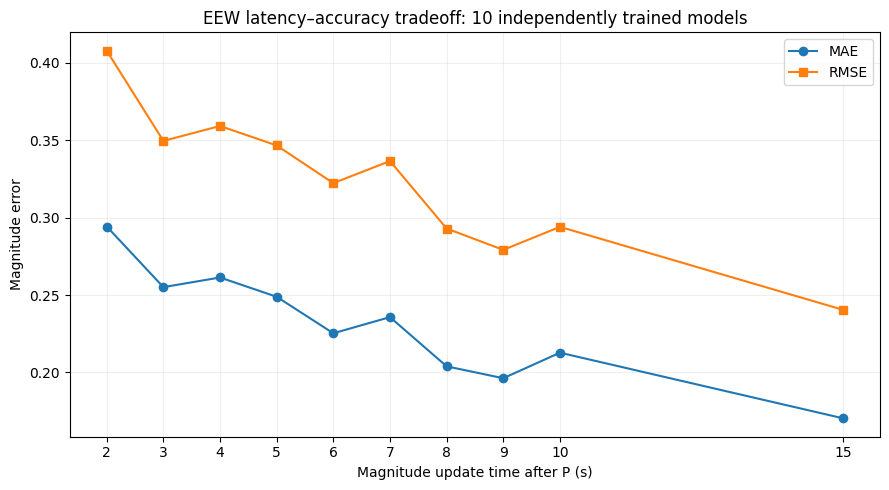

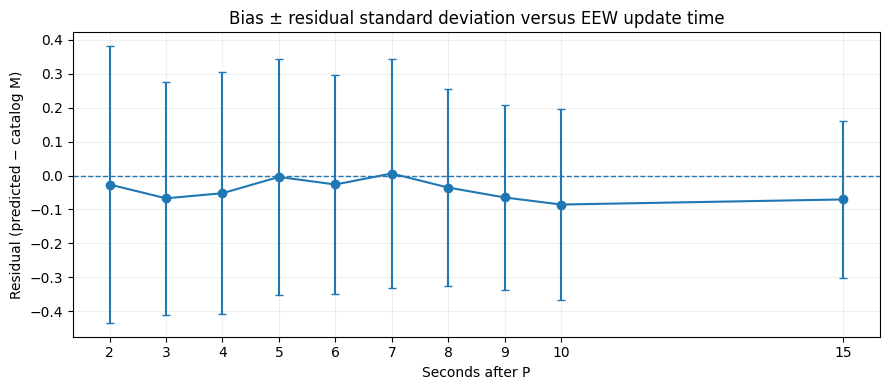

In [11]:
fig,ax=plt.subplots(figsize=(9,5))
ax.plot(summary_df.post_p_s,summary_df.test_mae,marker="o",label="MAE")
ax.plot(summary_df.post_p_s,summary_df.test_rmse,marker="s",label="RMSE")
ax.set(xlabel="Magnitude update time after P (s)",ylabel="Magnitude error",
       title="EEW latency–accuracy tradeoff: 10 independently trained models")
ax.set_xticks(POST_P_WINDOWS_S); ax.grid(alpha=.2); ax.legend(); plt.tight_layout()
plt.savefig(FIG_DIR/"latency_accuracy.png",dpi=200,bbox_inches="tight"); plt.show()

fig,ax=plt.subplots(figsize=(9,4))
ax.errorbar(summary_df.post_p_s,summary_df.test_bias,yerr=summary_df.test_std,marker="o",capsize=3)
ax.axhline(0,lw=1,ls="--"); ax.set(xlabel="Seconds after P",ylabel="Residual (predicted − catalog M)",
    title="Bias ± residual standard deviation versus EEW update time")
ax.set_xticks(POST_P_WINDOWS_S); ax.grid(alpha=.2); plt.tight_layout(); plt.show()


## 10. Accuracy by earthquake magnitude

Early windows can systematically underestimate larger earthquakes because rupture may still be evolving. This diagnostic reports MAE for all records and for increasingly important large-event subsets.


subset,M≥3,M≥4,M≥5,all
post_p_s,,,,
2,0.338078,0.516987,1.029921,0.294306
3,0.328513,0.512104,1.049933,0.255118
4,0.307006,0.576695,1.136893,0.261350
5,0.287997,0.359730,0.693668,0.248894
6,0.268398,0.361773,0.902012,0.225306
7,0.256816,0.366732,0.934752,0.235742
8,0.232983,0.405062,0.918469,0.203934
9,0.231397,0.405878,0.973677,0.196248
10,0.222780,0.399929,1.027388,0.212766


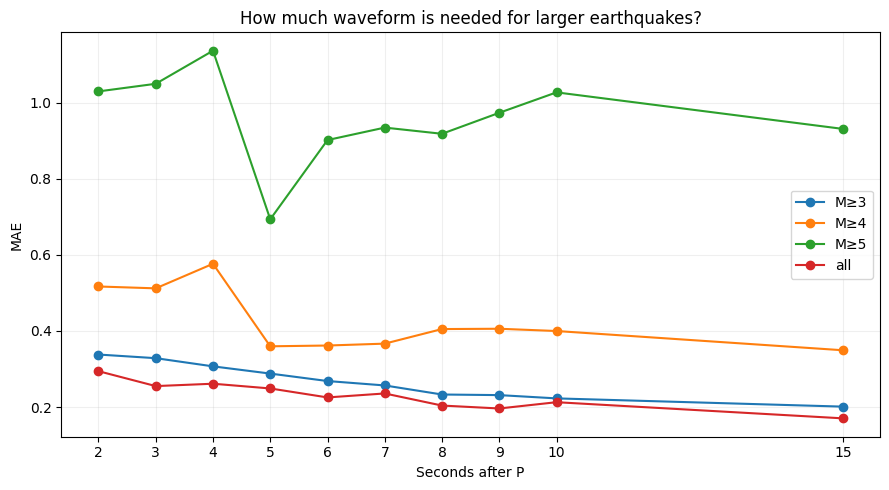

In [12]:
rows=[]
for T,d in pred_all.groupby("post_p_s"):
    for label,sel in [("all",np.ones(len(d),bool)),("M≥3",d.magnitude>=3),("M≥4",d.magnitude>=4),("M≥5",d.magnitude>=5)]:
        q=d[sel]
        rows.append(dict(post_p_s=T,subset=label,N=len(q),MAE=q.abs_error.mean() if len(q) else np.nan,
                         bias=q.residual.mean() if len(q) else np.nan))
mag_perf=pd.DataFrame(rows); mag_perf.to_csv(OUTPUT_DIR/"performance_by_magnitude.csv",index=False)
display(mag_perf.pivot(index="post_p_s",columns="subset",values="MAE"))

fig,ax=plt.subplots(figsize=(9,5))
for label,q in mag_perf.groupby("subset"):
    if q.MAE.notna().any(): ax.plot(q.post_p_s,q.MAE,marker="o",label=label)
ax.set(xlabel="Seconds after P",ylabel="MAE",title="How much waveform is needed for larger earthquakes?")
ax.set_xticks(POST_P_WINDOWS_S); ax.grid(alpha=.2); ax.legend(); plt.tight_layout(); plt.show()


## 11. Event-level network fusion

A real EEW system can combine estimates from several triggered stations. As a simple reference, we take the median single-station estimate for each event and horizon, then compare it with the catalog magnitude.


,post_p_s,event_MAE,N_events
0,2,0.155716,2176
1,3,0.153688,2176
2,4,0.146743,2176
3,5,0.134406,2176
4,6,0.126377,2176
5,7,0.129733,2176
6,8,0.121496,2176
7,9,0.123825,2176
8,10,0.144337,2176
9,15,0.123272,2176


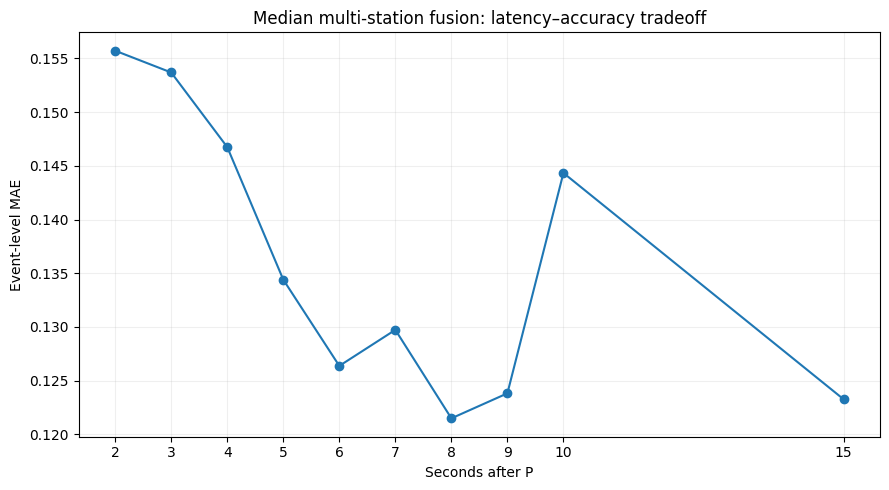

In [13]:
event_pred=(pred_all.groupby(["post_p_s","event_id"]).agg(
    catalog_magnitude=("magnitude","median"),predicted_magnitude=("predicted_magnitude","median"),
    n_stations=("station","nunique")).reset_index())
event_pred["residual"]=event_pred.predicted_magnitude-event_pred.catalog_magnitude
event_pred["abs_error"]=event_pred.residual.abs()
event_summary=event_pred.groupby("post_p_s").agg(event_MAE=("abs_error","mean"),N_events=("event_id","size")).reset_index()
event_summary.to_csv(OUTPUT_DIR/"event_level_summary.csv",index=False)
display(event_summary)
fig,ax=plt.subplots(figsize=(9,5)); ax.plot(event_summary.post_p_s,event_summary.event_MAE,marker="o")
ax.set(xlabel="Seconds after P",ylabel="Event-level MAE",title="Median multi-station fusion: latency–accuracy tradeoff")
ax.set_xticks(POST_P_WINDOWS_S); ax.grid(alpha=.2); plt.tight_layout(); plt.show()


## 12. Load any saved horizon model

The helper below ensures that later robustness tests use the correct independently trained checkpoint.


In [14]:
def load_model_for_horizon(T):
    path=MODEL_DIR/f"eqvit_magnitude_Pm1_Pp{T:02d}s_best.pt"
    ck=torch.load(path,map_location=DEVICE)
    m=EQViTMagnitude().to(DEVICE); m.load_state_dict(ck["state_dict"]); m.eval()
    return m,ck


## 13. Robustness benchmark

Accuracy alone is not sufficient for EEW. We test all ten models under the **same controlled perturbations**:

- P-pick timing errors: −0.5, +0.5, and +1.0 s;
- added Gaussian noise;
- common amplitude/gain perturbation;
- one missing horizontal component;
- clipping/saturation;
- a short telemetry gap.

Perturbations are applied only to the causally visible samples. This benchmark measures degradation relative to each model's clean test MAE.


In [15]:
@torch.no_grad()
def stress_mae(T,kind="clean",value=None,limit=None):
    model,_=load_model_for_horizon(T); frame=test_df if limit is None else test_df.iloc[:limit]
    ys=[]; ps=[]; rng=np.random.default_rng(SEED+int(T*1000)+123)
    visible_n=int((PRE_P_S+T)*FS)
    with h5py.File(H5_PATH,"r") as f:
        for a in range(0,len(frame),BATCH_SIZE*2):
            xx=[]; yy=[]
            for r in frame.iloc[a:a+BATCH_SIZE*2].itertuples():
                g=f[r.id]; x=np.asarray(g["data"],np.float32); p=float(g.attrs["p_arrival_sample"])
                if kind=="pick_shift": p += float(value)*FS
                w=extract_causal_window(x,p,T); baseline=w[:PRE_N].mean(0,keepdims=True); w[:visible_n]-=baseline
                v=w[:visible_n]
                if kind=="noise":
                    rms=np.sqrt(np.mean(v*v,axis=0,keepdims=True)+1e-12); v += rng.normal(0,1,v.shape)*rms*float(value)
                elif kind=="gain": v *= float(value)
                elif kind=="drop_component": v[:,1]=0
                elif kind=="clip":
                    q=np.quantile(np.abs(v),float(value));
                    if q>0: np.clip(v,-q,q,out=v)
                elif kind=="gap" and visible_n>50:
                    L=min(int(float(value)*FS),visible_n//3); st=max(PRE_N,min(visible_n-L,PRE_N+int(.5*FS))); v[st:st+L]=0
                w[:visible_n]=v; w[visible_n:]=0; xx.append(w); yy.append(float(g.attrs["magnitude"]))
            xb=torch.from_numpy(np.stack(xx).astype(np.float32)).to(DEVICE)
            ps.extend(model(xb).reshape(-1).cpu().numpy()); ys.extend(yy)
    del model; y=np.asarray(ys); p=np.asarray(ps); return float(np.mean(np.abs(p-y)))

STRESS_CASES=[("clean",None,"Clean"),("pick_shift",-.5,"P pick −0.5 s"),("pick_shift",.5,"P pick +0.5 s"),
              ("pick_shift",1.0,"P pick +1.0 s"),("noise",.20,"Added noise (20% RMS)"),
              ("gain",1.25,"Gain ×1.25"),("drop_component",None,"Missing horizontal"),
              ("clip",.97,"97% clipping threshold"),("gap",.30,"0.30-s gap")]

# For QUICK_RUN, cap stress-test records to keep this cell fast.
limit=min(1000,len(test_df)) if QUICK_RUN else None
stress_rows=[]
for T in POST_P_WINDOWS_S:
    print("stress horizon",T)
    for kind,value,label in STRESS_CASES:
        mae=stress_mae(T,kind,value,limit=limit)
        stress_rows.append(dict(post_p_s=T,scenario=label,MAE=mae))
stress_df=pd.DataFrame(stress_rows)
clean_map=stress_df[stress_df.scenario=="Clean"].set_index("post_p_s").MAE
stress_df["MAE_degradation"]=stress_df.apply(lambda r:r.MAE-clean_map.loc[r.post_p_s],axis=1)
stress_df.to_csv(OUTPUT_DIR/"robustness_benchmark.csv",index=False)
display(stress_df.pivot(index="post_p_s",columns="scenario",values="MAE"))


stress horizon 2
stress horizon 3
stress horizon 4
stress horizon 5
stress horizon 6
stress horizon 7
stress horizon 8
stress horizon 9
stress horizon 10
stress horizon 15


scenario,0.30-s gap,97% clipping threshold,Added noise (20% RMS),Clean,Gain ×1.25,Missing horizontal,P pick +0.5 s,P pick +1.0 s,P pick −0.5 s
post_p_s,,,,,,,,,
2,0.303384,0.308731,0.305162,0.294306,0.291766,0.359257,0.356507,0.446308,0.381932
3,0.256376,0.269994,0.261109,0.255118,0.241048,0.320846,0.329180,0.394694,0.300783
4,0.263844,0.276713,0.273562,0.261350,0.253226,0.351191,0.319742,0.413143,0.292945
5,0.248470,0.262149,0.259451,0.248894,0.252901,0.340789,0.287371,0.339709,0.282176
6,0.225019,0.238362,0.233741,0.225306,0.221832,0.341304,0.276036,0.343646,0.251161
7,0.235081,0.252389,0.243060,0.235742,0.238095,0.327820,0.275851,0.325628,0.259576
8,0.203433,0.217673,0.215137,0.203934,0.198374,0.315315,0.253875,0.326776,0.220694
9,0.195661,0.209710,0.205135,0.196248,0.179680,0.252357,0.245295,0.335875,0.203710
10,0.210910,0.224043,0.218197,0.212766,0.189285,0.288766,0.265589,0.336187,0.217852


## 14. Robustness visualization

Two views are useful: absolute MAE under each perturbation, and **degradation relative to clean data**. A model can have good clean accuracy but be operationally fragile; the degradation plot exposes that.


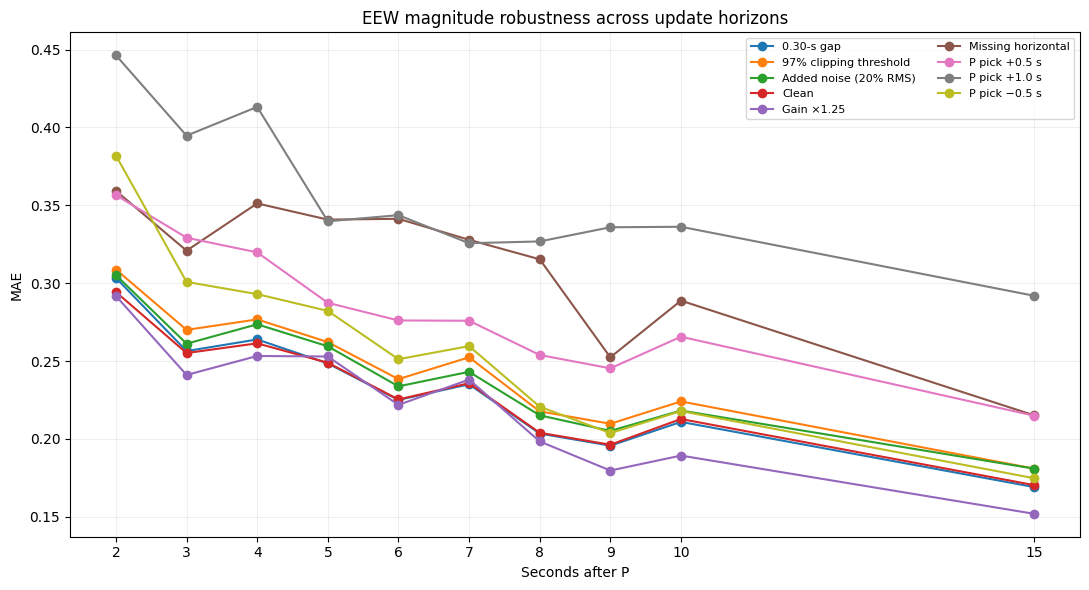

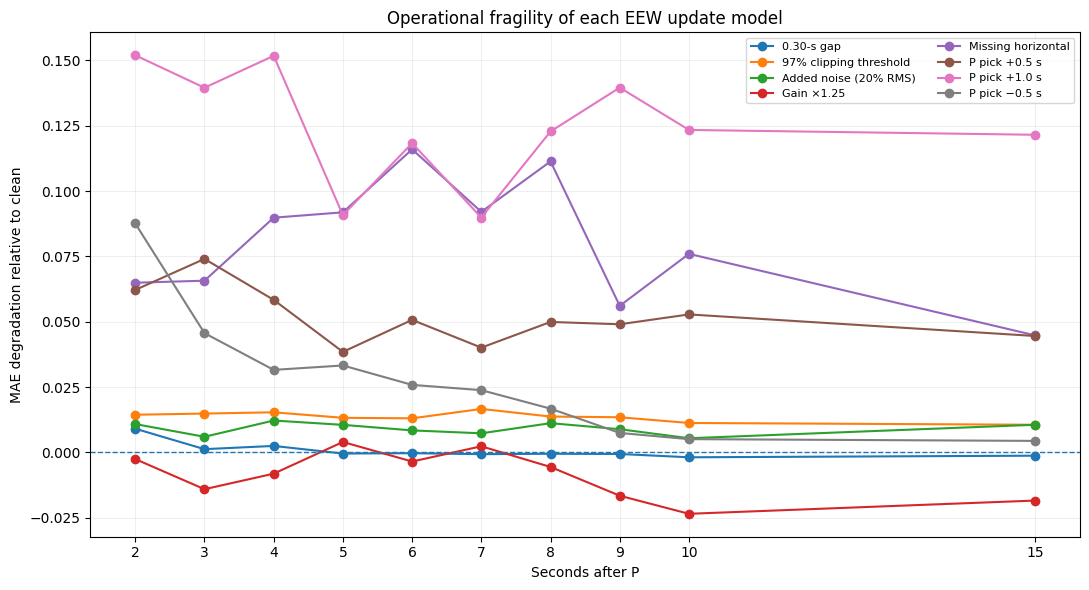

In [16]:
fig,ax=plt.subplots(figsize=(11,6))
for label,q in stress_df.groupby("scenario"):
    ax.plot(q.post_p_s,q.MAE,marker="o",label=label)
ax.set(xlabel="Seconds after P",ylabel="MAE",title="EEW magnitude robustness across update horizons")
ax.set_xticks(POST_P_WINDOWS_S); ax.grid(alpha=.2); ax.legend(ncol=2,fontsize=8); plt.tight_layout()
plt.savefig(FIG_DIR/"robustness_absolute_mae.png",dpi=200,bbox_inches="tight"); plt.show()

q=stress_df[stress_df.scenario!="Clean"]
fig,ax=plt.subplots(figsize=(11,6))
for label,d in q.groupby("scenario"):
    ax.plot(d.post_p_s,d.MAE_degradation,marker="o",label=label)
ax.axhline(0,ls="--",lw=1); ax.set(xlabel="Seconds after P",ylabel="MAE degradation relative to clean",
    title="Operational fragility of each EEW update model")
ax.set_xticks(POST_P_WINDOWS_S); ax.grid(alpha=.2); ax.legend(ncol=2,fontsize=8); plt.tight_layout(); plt.show()


## 15. SNR and station diagnostics

These tables help distinguish a true time-window effect from data-quality or station-response effects. Because every horizon uses the same test records, comparisons remain paired.


In [17]:
snr_rows=[]
for T,d in pred_all.groupby("post_p_s"):
    q=d[np.isfinite(d.snr_mean)].copy()
    if len(q)>20:
        try: q["snr_group"]=pd.qcut(q.snr_mean,4,duplicates="drop")
        except ValueError: continue
        for g,z in q.groupby("snr_group",observed=True):
            snr_rows.append(dict(post_p_s=T,snr_group=str(g),N=len(z),MAE=z.abs_error.mean()))
snr_perf=pd.DataFrame(snr_rows); snr_perf.to_csv(OUTPUT_DIR/"performance_by_snr.csv",index=False)

station_perf=(pred_all.groupby(["post_p_s","station"]).agg(N=("abs_error","size"),MAE=("abs_error","mean"),
              bias=("residual","mean")).reset_index())
station_perf.to_csv(OUTPUT_DIR/"performance_by_station.csv",index=False)
print("Saved SNR and station diagnostics.")


Saved SNR and station diagnostics.


## 16. Paired improvement relative to the 2-s model

Because the same test records are used at every horizon, we can compare each prediction directly with the 2-s baseline. This is more informative than comparing unrelated aggregate samples.


In [18]:
wide=pred_all.pivot_table(index="id",columns="post_p_s",values="abs_error",aggfunc="first")
paired=[]
for T in POST_P_WINDOWS_S:
    q=wide[[2,T]].dropna() if T!=2 else wide[[2]].dropna()
    delta=0.0 if T==2 else float((q[2]-q[T]).mean())
    improved=np.nan if T==2 else float((q[T]<q[2]).mean())
    paired.append(dict(post_p_s=T,mean_MAE_improvement_vs_2s=delta,fraction_records_improved=improved))
paired_df=pd.DataFrame(paired); paired_df.to_csv(OUTPUT_DIR/"paired_improvement_vs_2s.csv",index=False)
display(paired_df)


,post_p_s,mean_MAE_improvement_vs_2s,fraction_records_improved
0,2,0.000000,NaN
1,3,0.039188,0.547209
2,4,0.032955,0.530710
3,5,0.045412,0.565520
4,6,0.069000,0.599186
5,7,0.058564,0.581479
6,8,0.090372,0.626971
7,9,0.098058,0.634028
8,10,0.081540,0.593241
9,15,0.123982,0.669125


## 17. Final model manifest for operational use

The manifest records the exact meaning of every checkpoint. In deployment, select the model according to elapsed time since the automatic P pick. For example, at 4.3 s after P, the P+4-s model is causal and available; the P+5-s model is not yet allowed.


In [19]:
manifest=[]
for T in POST_P_WINDOWS_S:
    ck=MODEL_DIR/f"eqvit_magnitude_Pm1_Pp{T:02d}s_best.pt"
    manifest.append({"post_p_seconds":T,"start_relative_to_P_seconds":-PRE_P_S,
                     "end_relative_to_P_seconds":T,"visible_duration_seconds":PRE_P_S+T,
                     "model_tensor_samples":FULL_N,"model_tensor_end_relative_to_P_seconds":MODEL_POST_P_S,
                     "future_samples_zero_masked":True,"checkpoint":str(ck),"causal":True})
with open(OUTPUT_DIR/"model_manifest.json","w") as f: json.dump(manifest,f,indent=2)
print(json.dumps(manifest,indent=2))


[
  {
    "post_p_seconds": 2,
    "start_relative_to_P_seconds": -1.0,
    "end_relative_to_P_seconds": 2,
    "visible_duration_seconds": 3.0,
    "model_tensor_samples": 3000,
    "model_tensor_end_relative_to_P_seconds": 29.0,
    "future_samples_zero_masked": true,
    "checkpoint": "outputs/txed_eqvit_magnitude_multiwindow_eew/models/eqvit_magnitude_Pm1_Pp02s_best.pt",
    "causal": true
  },
  {
    "post_p_seconds": 3,
    "start_relative_to_P_seconds": -1.0,
    "end_relative_to_P_seconds": 3,
    "visible_duration_seconds": 4.0,
    "model_tensor_samples": 3000,
    "model_tensor_end_relative_to_P_seconds": 29.0,
    "future_samples_zero_masked": true,
    "checkpoint": "outputs/txed_eqvit_magnitude_multiwindow_eew/models/eqvit_magnitude_Pm1_Pp03s_best.pt",
    "causal": true
  },
  {
    "post_p_seconds": 4,
    "start_relative_to_P_seconds": -1.0,
    "end_relative_to_P_seconds": 4,
    "visible_duration_seconds": 5.0,
    "model_tensor_samples": 3000,
    "model_tensor_end

# Interpretation for EEW

The final scientific product is not simply “which model has the lowest MAE?” It is the **magnitude-information growth curve after P arrival**.

1. **P+2 to P+4 s:** earliest warning regime. These models should be judged by whether they provide useful first estimates before much of the rupture/coda is available.
2. **P+5 to P+10 s:** revision regime. Accuracy should improve as additional P energy, converted phases, S energy, and source duration enter the causal window.
3. **P+15 s:** late reference within this experiment. It provides a practical upper benchmark for how much the same architecture gains from additional waveform duration.
4. **Large events matter disproportionately.** Inspect the M≥3/M≥4/M≥5 curves for saturation or early underestimation; overall MAE can be dominated by small events.
5. **Robustness matters independently of clean MAE.** An EEW model must tolerate imperfect EQCCT picks, low SNR, missing channels, clipping, and telemetry gaps.

## Recommended next experiment

After establishing these manual-P-centered reference curves, repeat the exact ten-horizon experiment with **EQCCT-torch automatic P picks** and compare manual-P versus EQCCT-P results using the same event split. That gives the most direct estimate of the operational performance loss introduced by the picker and completes the causal TexasEEW magnitude-estimation benchmark.
